In [33]:
from coronary_analysis.utils import show_image
import cv2
from sklearn.model_selection import train_test_split

In [34]:
import os
import zipfile
import urllib.request


def download_and_unzip(url: str, zip_path: str, extract_dir: str):
    os.makedirs(os.path.dirname(zip_path), exist_ok=True)
    os.makedirs(extract_dir, exist_ok=True)

    if os.path.exists(zip_path):
        return

    urllib.request.urlretrieve(url, zip_path)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

Dataset for Automatic Region-based Coronary Artery Disease Diagnostics Using X-Ray Angiography Images: 
https://www.nature.com/articles/s41597-023-02871-z

In [35]:
url = "https://zenodo.org/records/10390295/files/arcade.zip"
zip_path = "downloads/arcade.zip"
extract_dir = "raw_datasets/arcade"

download_and_unzip(url, zip_path, extract_dir)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Selected image_id: 1
Image info: {'id': 1, 'width': 512, 'height': 512, 'file_name': '1.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
Annotation IDs: [1]
Annotations:
{'id': 1, 'image_id': 1, 'category_id': 26, 'segmentation': [[229.53, 236.06, 236.6, 248.0, 249.1, 267.7, 257.46, 286.28, 269.05, 278.85, 261.9, 263.4, 252.1, 245.5, 244.09, 236.06, 240.22, 230.42]], 'area': 768.0, 'bbox': [229.53, 230.42, 39.52, 55.86], 'iscrowd': 0, 'attributes': {'occluded': False}}
ann.image_id == selected? True


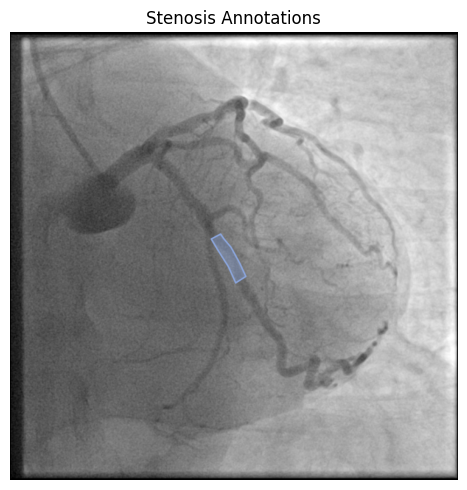

In [36]:
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import numpy as np

# na zbiorze train ten kod nie zadziala ponieważ z jakiegos powodu id annotacji są zduplikowane
ROOT = "raw_datasets/arcade/arcade/stenosis/test"
IMG_DIR = os.path.join(ROOT, "images")
ANN_FILE = os.path.join(ROOT, "annotations", "test.json")

coco = COCO(ANN_FILE)

img_id = coco.getImgIds()[0]
print("Selected image_id:", img_id)

img_info = coco.loadImgs([img_id])[0]
print("Image info:", img_info)

img = cv2.imread(os.path.join(IMG_DIR, img_info["file_name"]), cv2.IMREAD_GRAYSCALE)

ann_ids = coco.getAnnIds(imgIds=[img_id])
print("Annotation IDs:", ann_ids)

anns = coco.loadAnns(ann_ids)
print("Annotations:")
for ann in anns:
    print(ann)
    print("ann.image_id == selected?", ann["image_id"] == img_id)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img, cmap="gray")
ax.axis("off")
plt.sca(ax)
coco.showAnns(anns)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
fig.canvas.draw()
img_with_anns = np.array(fig.canvas.renderer.buffer_rgba(), dtype=np.uint8)[..., :3]
plt.close(fig)

show_image(img_with_anns, titles=["Stenosis Annotations"])

Database X-ray Coronary Angiograms (DCA1): http://personal.cimat.mx:8181/~ivan.cruz/DB_Angiograms.html lub https://www.kaggle.com/datasets/bard2024/database-x-ray-coronary-angiograms-dca1

In [37]:
url = (
    "http://personal.cimat.mx:8181/~ivan.cruz/DB_Angiograms_files/DB_Angiograms_134.zip"
)
zip_path = "downloads/DCA1.zip"
extract_dir = "raw_datasets/DCA1"

download_and_unzip(url, zip_path, extract_dir)

In [38]:
DCA1_ROOT = "raw_datasets/DCA1/Database_134_Angiograms"

In [39]:
from coronary_analysis.datasets import get_dca1_pairs

if "train" not in os.listdir(DCA1_ROOT):
    dca1_pairs = get_dca1_pairs(image_dir="raw_datasets/DCA1/Database_134_Angiograms")
    train_pairs, test_pairs = train_test_split(
        dca1_pairs, test_size=0.3, random_state=42
    )
    val_pairs, test_pairs = train_test_split(test_pairs, test_size=0.5, random_state=42)

    for split_name, pairs in zip(
        ["train", "val", "test"], [train_pairs, val_pairs, test_pairs]
    ):
        split_dir = os.path.join(DCA1_ROOT, split_name)
        os.makedirs(split_dir, exist_ok=True)
        for img_filename, gt_filename in pairs:
            img_path = os.path.join(DCA1_ROOT, img_filename)
            gt_path = os.path.join(DCA1_ROOT, gt_filename)

            os.rename(img_path, os.path.join(split_dir, img_filename))
            os.rename(gt_path, os.path.join(split_dir, gt_filename))

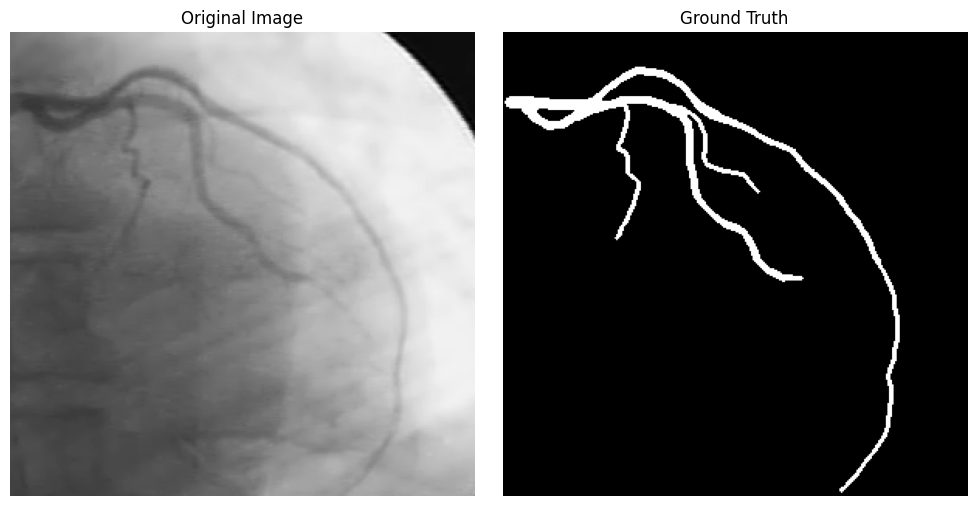

In [40]:
from coronary_analysis.datasets import DCA1Dataset

dataset = DCA1Dataset(os.path.join(DCA1_ROOT, "train"))
image, image_gt = dataset[0]

show_image(
    image.squeeze(), image_gt.squeeze(), titles=["Original Image", "Ground Truth"]
)

LM-CAD and FS-CAD from https://www.nature.com/articles/s41598-024-71063-5

In [41]:
url = "https://drive.usercontent.google.com/download?id=152rQcHhYkD_68KcWYDiZ1ExSM7v7AT_x&export=download&confirm=t"
zip_path = "downloads/LM-CAD.zip"
extract_dir = "raw_datasets/LM-CAD"

download_and_unzip(url, zip_path, extract_dir)

In [42]:
from coronary_analysis.datasets import (
    LMCADDataset,
    get_lm_cad_pairs,
    FSCADDataset,
    get_fs_cad_pairs,
)

lmcad_test_pairs = get_lm_cad_pairs("raw_datasets/LM-CAD/LM-CAD/train")

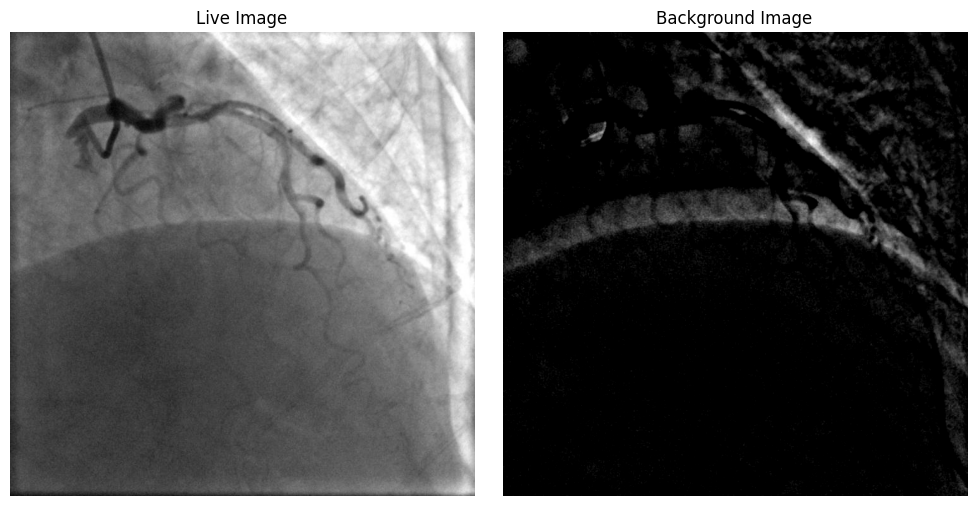

In [43]:
lm_cad_ds = LMCADDataset(
    "raw_datasets/LM-CAD/LM-CAD/train", lmcad_test_pairs, transform=None
)

img, img_bg = lm_cad_ds[0]
show_image(img.squeeze(), img_bg.squeeze(), titles=["Live Image", "Background Image"])

In [44]:
url = "https://drive.usercontent.google.com/download?id=19Mi1UJUT3ZZfsEMoeiOamRhW6PEWqZ5S&export=download"
zip_path = "downloads/FS-CAD.zip"
extract_dir = "raw_datasets/FS-CAD"

download_and_unzip(url, zip_path, extract_dir)

In [45]:
FS_CAD_ROOT = "raw_datasets/FS-CAD/FS-CAD"

In [46]:
import shutil

if "train" not in os.listdir(FS_CAD_ROOT):
    fs_cad_pairs = get_fs_cad_pairs(FS_CAD_ROOT)

    train_pairs, test_pairs = train_test_split(
        fs_cad_pairs, test_size=0.25, random_state=42
    )
    val_pairs, test_pairs = train_test_split(test_pairs, test_size=0.5, random_state=42)

    for split_name, pairs in zip(
        ["train", "val", "test"], [train_pairs, val_pairs, test_pairs]
    ):
        split_dir = os.path.join(FS_CAD_ROOT, split_name)
        os.makedirs(split_dir, exist_ok=True)
        os.makedirs(os.path.join(split_dir, "A"), exist_ok=True)
        os.makedirs(os.path.join(split_dir, "GT"), exist_ok=True)

        for img_filename, mask_filename in pairs:
            img_path = os.path.join(FS_CAD_ROOT, "A", img_filename)
            mask_path = os.path.join(FS_CAD_ROOT, "GT", mask_filename)

            os.rename(img_path, os.path.join(split_dir, "A", img_filename))
            os.rename(mask_path, os.path.join(split_dir, "GT", mask_filename))

    shutil.rmtree(os.path.join(FS_CAD_ROOT, "A"))
    shutil.rmtree(os.path.join(FS_CAD_ROOT, "GT"))
    shutil.rmtree(os.path.join(FS_CAD_ROOT, ".ipynb_checkpoints"))

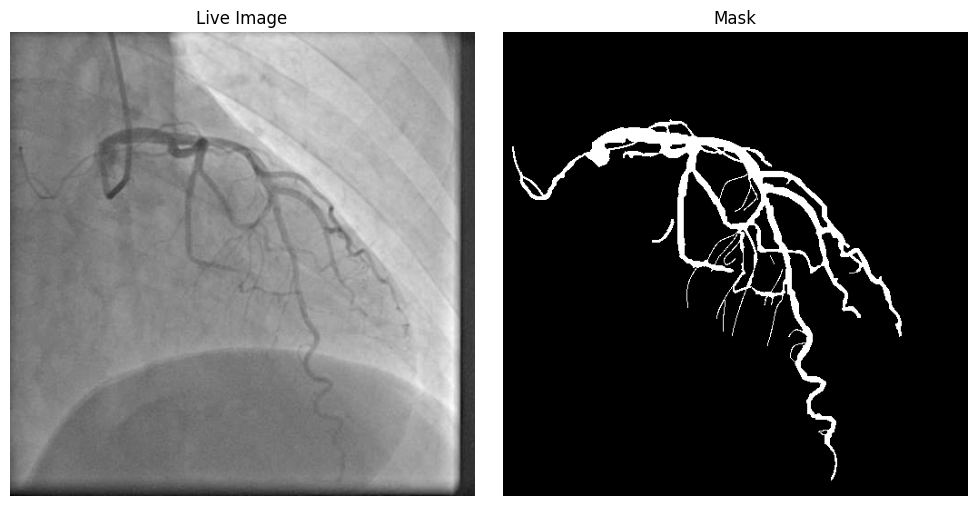

In [47]:
fs_cad_ds = FSCADDataset(f"{FS_CAD_ROOT}/train")

img, mask = fs_cad_ds[0]
show_image(img.squeeze(), mask.squeeze(), titles=["Live Image", "Mask"])

CoronaryDominance: Angiogram dataset for coronary dominance classification: https://huggingface.co/datasets/BearSubj13/CoronaryDominance

In [48]:
from datasets import load_dataset

ds = load_dataset("BearSubj13/CoronaryDominance")

In [49]:
ds

DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 1
    })
})